In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    LabelEncoder
)

df = pd.read_csv("adult_with_headers (1).csv")

print(df.head())


print("Rows and columns:", df.shape)

print("Column Names:")
print(df.columns.tolist())

print("Dataset Information:")
df.info()

print("Statistical Summary:")
print(df.describe(include="all"))

print("Data Types:")
print(df.dtypes)

print("Missing Values:")
print(df.isnull().sum())


missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

print(missing_percentage)


print(df.columns.tolist())

print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())

   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0          2174             0              40   United-States   <=50

In [15]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

for column in categorical_columns:
    print("\n", column)
    print("Number of unique categories:", df[column].nunique())
    print(df[column].unique())

    #handle missing
    df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values after imputation:")
print(df.isnull().sum())

print((df == '?').sum())


df = df.replace('?', np.nan)

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print(df.isnull().sum())

Numerical Columns:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

Categorical Columns:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']

 workclass
Number of unique categories: 9
[' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked']

 education
Number of unique categories: 16
[' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th']

 marital_status
Number of unique categories: 7
[' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated' ' Married-AF-spouse' ' Widowed']

 occupation
Number of unique categories: 15
[' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'


### Missing Value Handling

Missing values in categorical variables were handled using mode imputation.
The mode is the most frequently occurring category and is suitable for
categorical variables because it does not introduce a new artificial category.

Rows were not removed because unnecessary deletion could reduce the available
training data.

Total missing values: 0


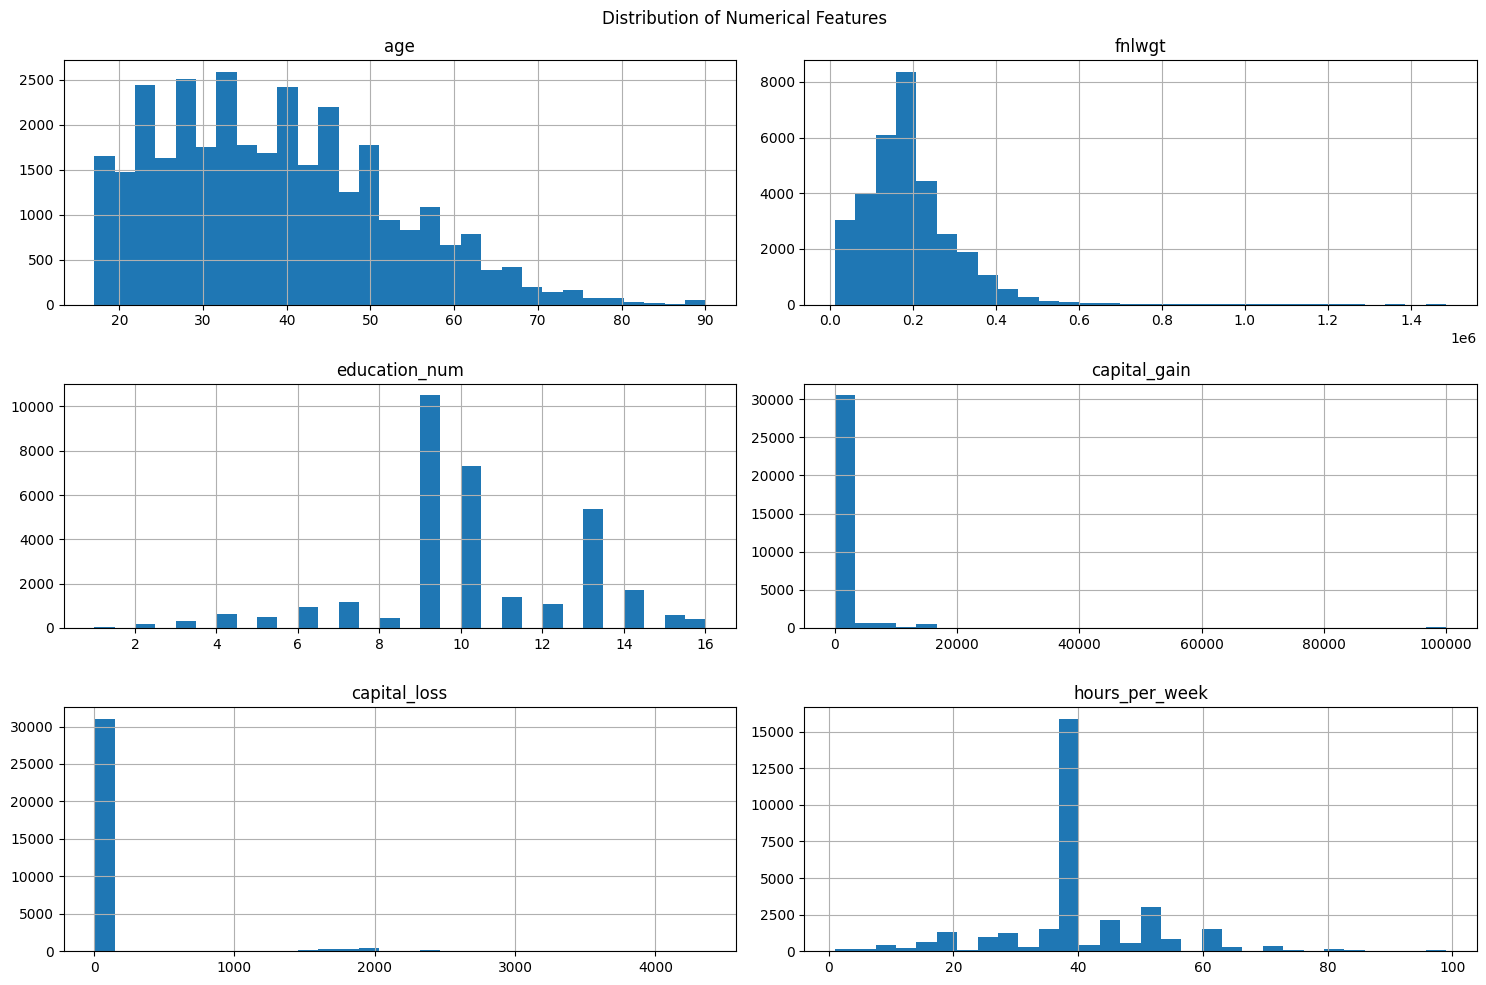

Skewness of numerical features:
capital_gain      11.953848
capital_loss       4.594629
fnlwgt             1.446980
age                0.558743
hours_per_week     0.227643
education_num     -0.311676
dtype: float64


In [20]:
print("Total missing values:", df.isnull().sum().sum())

df[numerical_columns].hist(
    figsize=(15, 10),
    bins=30
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()


skewness = df[numerical_columns].skew().sort_values(ascending=False)

print("Skewness of numerical features:")
print(skewness)



In [28]:
print("Capital Gain Skewness:")
print(df['capital_gain'].skew())

df['capital_gain_log'] = np.log1p(df['capital_gain'])

print(df[['capital_gain', 'capital_gain_log']].head())

print("Original skewness:",
      df['capital_gain'].skew())

print("Log-transformed skewness:",
      df['capital_gain_log'].skew())

Capital Gain Skewness:
11.953847687699799
   capital_gain  capital_gain_log
0          2174          7.684784
1             0          0.000000
2             0          0.000000
3             0          0.000000
4             0          0.000000
Original skewness: 11.953847687699799
Log-transformed skewness: 3.096143524467517


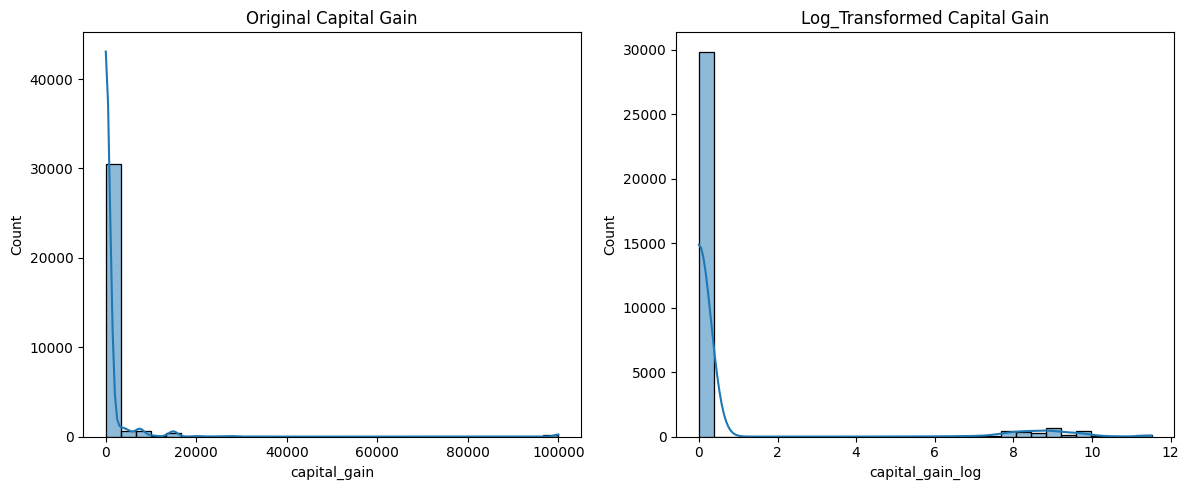

In [30]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

sns.histplot(
    df['capital_gain'],
    bins=30,
    kde=True
)

plt.title("Original Capital Gain")


plt.subplot(1, 2, 2)

sns.histplot(
    df['capital_gain_log'],
    bins=30,
    kde=True
)

plt.title("Log_Transformed Capital Gain")

plt.tight_layout()
plt.show()

### Log Transformation

The `capital-gain` feature is highly right-skewed because most observations
have relatively small values while a small number of observations have very
large values.

A log transformation using `log1p()` was applied to reduce the effect of
extreme values and make the distribution more suitable for machine learning
algorithms.

`log1p(x)` calculates `log(1 + x)` and is preferred here because the feature
contains zero values.

In [31]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 50, 100],
    labels=[
        'Young',
        'Adult',
        'Middle_Aged',
        'Senior'
    ]
)

print(df[['age', 'age_group']].head(10))

   age    age_group
0   39  Middle_Aged
1   50  Middle_Aged
2   38  Middle_Aged
3   53       Senior
4   28        Adult
5   37  Middle_Aged
6   49  Middle_Aged
7   52       Senior
8   31        Adult
9   42  Middle_Aged


### Feature 1: Age Group

The `age_group` feature categorizes individuals into meaningful age ranges.
This may help the model capture different income patterns across age groups
rather than relying only on the continuous age value.

In [33]:
df['work_hours_category'] = pd.cut(
    df['hours_per_week'],
    bins=[0, 20, 40, 60, 100],
    labels=[
        'Part_Time',
        'Full_Time',
        'Overtime',
        'Very_High'
    ]
)

print(
    df[
        ['hours_per_week', 'work_hours_category']
    ].head(10)
)

   hours_per_week work_hours_category
0              40           Full_Time
1              13           Part_Time
2              40           Full_Time
3              40           Full_Time
4              40           Full_Time
5              40           Full_Time
6              16           Part_Time
7              45            Overtime
8              50            Overtime
9              40           Full_Time


### Feature 2: Work Hours Category

The `work_hours_category` feature groups weekly working hours into categories.
This can help identify differences between part-time, full-time, overtime, and
very high working-hour groups that may be associated with income levels.

In [36]:
print("Updated Dataset:")
print(df.head())

print("\nNew Dataset Shape:")
print(df.shape)

#OHE
categorical_columns = df.select_dtypes(
    include='object'
).columns.tolist()

low_cardinality_columns = [
    column
    for column in categorical_columns
    if df[column].nunique() < 5
]

print("Categorical columns with fewer than 5 categories:")
print(low_cardinality_columns)

df_one_hot = pd.get_dummies(
    df,
    columns=low_cardinality_columns,
    drop_first=True
)

print("Shape after One-Hot Encoding:")
print(df_one_hot.shape)

print(df_one_hot.head())

Updated Dataset:
   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  \
0          2174             0              40   Un

### One-Hot Encoding

One-Hot Encoding converts categorical values into separate binary columns.

It is appropriate for categorical variables with a small number of categories
because it avoids creating an artificial numerical order between categories.

For example, categories such as Male and Female can be represented using
binary values rather than assigning arbitrary numerical values.

In [38]:
high_cardinality_columns = [
    column
    for column in categorical_columns
    if df[column].nunique() > 5
]

print("Categorical columns with more than 5 categories:")
print(high_cardinality_columns)

Categorical columns with more than 5 categories:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'native_country']


In [39]:
df_encoded = df.copy()

label_encoders = {}

for column in high_cardinality_columns:
    encoder = LabelEncoder()

    df_encoded[column] = encoder.fit_transform(
        df_encoded[column].astype(str)
    )

    label_encoders[column] = encoder

print(df_encoded.head())

   age  workclass  fnlwgt  education  education_num  marital_status  \
0   39          7   77516          9             13               4   
1   50          6   83311          9             13               2   
2   38          4  215646         11              9               0   
3   53          4  234721          1              7               2   
4   28          4  338409          9             13               2   

   occupation  relationship    race      sex  capital_gain  capital_loss  \
0           1             1   White     Male          2174             0   
1           4             0   White     Male             0             0   
2           6             1   White     Male             0             0   
3           6             0   Black     Male             0             0   
4          10             5   Black   Female             0             0   

   hours_per_week  native_country  income  capital_gain_log    age_group  \
0              40              39   <=50

### Label Encoding

Label Encoding converts each category into an integer value.

It is useful when a categorical variable has many categories because One-Hot
Encoding could create a very large number of columns.

However, Label Encoding may introduce an artificial numerical ordering between
categories even when no natural ordering exists. Therefore, it should be used
carefully, especially with models that interpret numerical values directly.

## One-Hot Encoding vs Label Encoding

### One-Hot Encoding

**Advantages:**
- Does not create an artificial order between categories.
- Works well for categorical variables with a small number of categories.
- Easy for machine learning models to interpret.

**Disadvantages:**
- Can create many additional columns when there are many categories.
- Can increase memory usage and computational complexity.

### Label Encoding

**Advantages:**
- Simple and memory efficient.
- Does not increase the number of columns.
- Useful when categorical variables contain many categories.

**Disadvantages:**
- Can create an artificial numerical relationship between categories.
- The assigned numbers do not necessarily represent actual ranking.

In [44]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print(numerical_columns)


standard_scaler = StandardScaler()

standard_scaled = standard_scaler.fit_transform(
    df[numerical_columns]
)

standard_scaled_df = pd.DataFrame(
    standard_scaled,
    columns=numerical_columns
)

print(standard_scaled_df.head())


print("Means after Standard Scaling:")
print(standard_scaled_df.mean().round(2))

print("\nStandard deviations after Standard Scaling:")
print(standard_scaled_df.std().round(2))


minmax_scaler = MinMaxScaler()

minmax_scaled = minmax_scaler.fit_transform(
    df[numerical_columns]
)

minmax_scaled_df = pd.DataFrame(
    minmax_scaled,
    columns=numerical_columns
)

print(minmax_scaled_df.head())

print("Minimum values:")
print(minmax_scaled_df.min())

print("\nMaximum values:")
print(minmax_scaled_df.max())

['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'capital_gain_log']
        age    fnlwgt  education_num  capital_gain  capital_loss  \
0  0.030671 -1.063611       1.134739      0.148453      -0.21666   
1  0.837109 -1.008707       1.134739     -0.145920      -0.21666   
2 -0.042642  0.245079      -0.420060     -0.145920      -0.21666   
3  1.057047  0.425801      -1.197459     -0.145920      -0.21666   
4 -0.775768  1.408176       1.134739     -0.145920      -0.21666   

   hours_per_week  capital_gain_log  
0       -0.035429          2.831370  
1       -2.222153         -0.299271  
2       -0.035429         -0.299271  
3       -0.035429         -0.299271  
4       -0.035429         -0.299271  
Means after Standard Scaling:
age                -0.0
fnlwgt             -0.0
education_num       0.0
capital_gain        0.0
capital_loss        0.0
hours_per_week     -0.0
capital_gain_log    0.0
dtype: float64

Standard deviations after Standard Scaling:


## Standard Scaling vs Min-Max Scaling

### Standard Scaling

Standard Scaling transforms the data so that the feature has a mean close to
0 and a standard deviation close to 1.

It is useful for algorithms that work better when features are centered and
have similar variance, such as Logistic Regression, Support Vector Machines,
and many optimization-based algorithms.

Standard Scaling can still be affected by extreme outliers.

### Min-Max Scaling

Min-Max Scaling transforms values into a fixed range, usually 0 to 1.

It is useful when a model requires features to be within a specific range and
is commonly used for neural networks and distance-based algorithms.

However, Min-Max Scaling is sensitive to outliers because the minimum and
maximum values determine the scaling range.

In [45]:
print("Final Dataset Information:")
df_encoded.info()

print("\nFinal Dataset Shape:")
print(df_encoded.shape)

print("\nRemaining Missing Values:")
print(df_encoded.isnull().sum().sum())

Final Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   age                  32561 non-null  int64   
 1   workclass            32561 non-null  int64   
 2   fnlwgt               32561 non-null  int64   
 3   education            32561 non-null  int64   
 4   education_num        32561 non-null  int64   
 5   marital_status       32561 non-null  int64   
 6   occupation           32561 non-null  int64   
 7   relationship         32561 non-null  int64   
 8   race                 32561 non-null  object  
 9   sex                  32561 non-null  object  
 10  capital_gain         32561 non-null  int64   
 11  capital_loss         32561 non-null  int64   
 12  hours_per_week       32561 non-null  int64   
 13  native_country       32561 non-null  int64   
 14  income               32561 non-null  object

## Conclusion

The Adult Income dataset was explored and prepared for machine learning.

Missing values were identified and handled using appropriate imputation
techniques. Numerical variables were examined for skewness, and the
`capital-gain` variable was log-transformed using `log1p()` to reduce the
effect of its strong right skew.

Two new features were created:

1. `age_group` - categorizes individuals into meaningful age ranges.
2. `work_hours_category` - categorizes individuals according to weekly working
   hours.

One-Hot Encoding was applied to categorical variables with fewer than five
categories, while Label Encoding was demonstrated for categorical variables
with more than five categories.

Both Standard Scaling and Min-Max Scaling were applied to numerical features.
Standard Scaling centers the data around zero with unit variance, while
Min-Max Scaling transforms values into a fixed range between zero and one.

The resulting dataset is now prepared for further machine learning modeling.